# **Solving Functional Equations**

**Example:** Solving the functional equation  $f(x+y) = f(x)  f(y)$, with  $x$ and $y$ real numbers. Its solution is an exponential function, $f(x) = a^x$, with a real nonzero constant. In the next code we consider the initial condition $f(1)=2$, so the solution will be $f(x) = 2^x$.

Epoch 1/50 - loss: 0.453347
Epoch 2/50 - loss: 0.055865
Epoch 3/50 - loss: 0.025369
Epoch 4/50 - loss: 0.019277
Epoch 5/50 - loss: 0.016476
Epoch 6/50 - loss: 0.015512
Epoch 7/50 - loss: 0.025583
Epoch 8/50 - loss: 0.021308
Epoch 9/50 - loss: 0.012147
Epoch 10/50 - loss: 0.010545
Epoch 11/50 - loss: 0.010673
Epoch 12/50 - loss: 0.017296
Epoch 13/50 - loss: 0.020921
Epoch 14/50 - loss: 0.020498
Epoch 15/50 - loss: 0.010886
Epoch 16/50 - loss: 0.011706
Epoch 17/50 - loss: 0.018807
Epoch 18/50 - loss: 0.022348
Epoch 19/50 - loss: 0.023244
Epoch 20/50 - loss: 0.015376
Epoch 21/50 - loss: 0.051705
Epoch 22/50 - loss: 0.010587
Epoch 23/50 - loss: 0.020183
Epoch 24/50 - loss: 0.009546
Epoch 25/50 - loss: 0.020511
Epoch 26/50 - loss: 0.195277
Epoch 27/50 - loss: 0.029432
Epoch 28/50 - loss: 0.013363
Epoch 29/50 - loss: 0.009289
Epoch 30/50 - loss: 0.009342
Epoch 31/50 - loss: 0.009548
Epoch 32/50 - loss: 0.007221
Epoch 33/50 - loss: 0.008292
Epoch 34/50 - loss: 0.009296
Epoch 35/50 - loss: 0.0

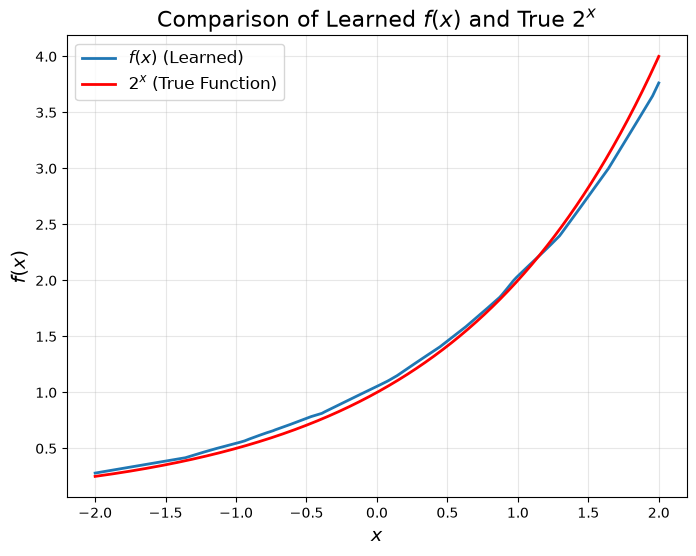

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Generate random samples for x_i and y_i
x_samples = np.random.uniform(-2, 2, 1000).reshape(-1, 1)
y_samples = np.random.uniform(-2, 2, 1000).reshape(-1, 1)

# Compute x + y for functional equation training
xy_samples = x_samples + y_samples

# Convert samples to PyTorch tensors
x_samples_t = torch.tensor(x_samples, dtype=torch.float32)
y_samples_t = torch.tensor(y_samples, dtype=torch.float32)
xy_samples_t = torch.tensor(xy_samples, dtype=torch.float32)

# Build the neural network
class FunctionalEquationNN(nn.Module):
    def __init__(self):
        super(FunctionalEquationNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 100),
            nn.ReLU(),
            # First hidden layer with 100 neurons
            nn.Linear(100, 50),
            nn.ReLU(),
            # Second hidden layer
            nn.Linear(50, 1)  # Output layer
        )

    def forward(self, x):
        return self.net(x)

model = FunctionalEquationNN()

# Define the custom loss function
def custom_loss(model, x_input, y_input, xy_input):
    # Functional equation loss: f(x+y) ≈ f(x)f(y)
    f_x = model(x_input)  # f(x)
    f_y = model(y_input)  # f(y)
    f_xy = model(xy_input)  # f(x+y)
    functional_loss = torch.mean((f_xy - f_x * f_y) ** 2)

    # Boundary condition loss: f(1) ≈ 2
    f_1 = model(torch.tensor([[1.0]], dtype=torch.float32))  # f(1)
    boundary_loss = (f_1 - 2.0) ** 2

    # Total loss: L = L_fct + L_bd
    return functional_loss + boundary_loss

# Compile the model (define optimizer)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
epochs = 50
batch_size = 32
n_samples = x_samples_t.shape[0]

for epoch in range(epochs):
    permutation = torch.randperm(n_samples)
    epoch_loss = 0.0
    n_batches = 0

    for i in range(0, n_samples, batch_size):
        indices = permutation[i:i + batch_size]
        x_batch = x_samples_t[indices]
        y_batch = y_samples_t[indices]
        xy_batch = xy_samples_t[indices]

        optimizer.zero_grad()
        loss = custom_loss(model, x_batch, y_batch, xy_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    print(f"Epoch {epoch + 1}/{epochs} - loss: {epoch_loss / n_batches:.6f}")

# Predict and plot the function f(x)
x_plot = np.linspace(-2, 2, 1000).reshape(-1, 1)
x_plot_t = torch.tensor(x_plot, dtype=torch.float32)

model.eval()
with torch.no_grad():
    f_x_plot = model(x_plot_t).numpy()

# Compute the true function y = 2^x for comparison
true_f_x = 2**x_plot

# Plot the learned function f(x) and the true function y = 2^x
plt.figure(figsize=(8, 6))
plt.plot(x_plot, f_x_plot, label="$f(x)$ (Learned)", linewidth=2)
plt.plot(x_plot, true_f_x, label="$2^x$ (True Function)", linewidth=2, color='red')
plt.title("Comparison of Learned $f(x)$ and True $2^x$", fontsize=16)
plt.xlabel("$x$", fontsize=14)
plt.ylabel("$f(x)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

**Example:** Solving the functional equation  $f(x+y) = f(x)+f(y)$, $x$ and $y$ real numbers.Its solution is a linear function, $f(x) = cx$, with $c$ real constant. In the next code we consider the initial condition $f(1)=3$, so the solution will be $f(x) = 3x$.

Epoch 1/30 - loss: 6.3427
Epoch 2/30 - loss: 1.3343
Epoch 3/30 - loss: 0.3419
Epoch 4/30 - loss: 0.0680
Epoch 5/30 - loss: 0.0110
Epoch 6/30 - loss: 0.0070
Epoch 7/30 - loss: 0.0065
Epoch 8/30 - loss: 0.0060
Epoch 9/30 - loss: 0.0055
Epoch 10/30 - loss: 0.0050
Epoch 11/30 - loss: 0.0046
Epoch 12/30 - loss: 0.0041
Epoch 13/30 - loss: 0.0037
Epoch 14/30 - loss: 0.0032
Epoch 15/30 - loss: 0.0029
Epoch 16/30 - loss: 0.0025
Epoch 17/30 - loss: 0.0022
Epoch 18/30 - loss: 0.0020
Epoch 19/30 - loss: 0.0018
Epoch 20/30 - loss: 0.0016
Epoch 21/30 - loss: 0.0014
Epoch 22/30 - loss: 0.0012
Epoch 23/30 - loss: 0.0011
Epoch 24/30 - loss: 0.0009
Epoch 25/30 - loss: 0.0008
Epoch 26/30 - loss: 0.0007
Epoch 27/30 - loss: 0.0006
Epoch 28/30 - loss: 0.0006
Epoch 29/30 - loss: 0.0005
Epoch 30/30 - loss: 0.0005


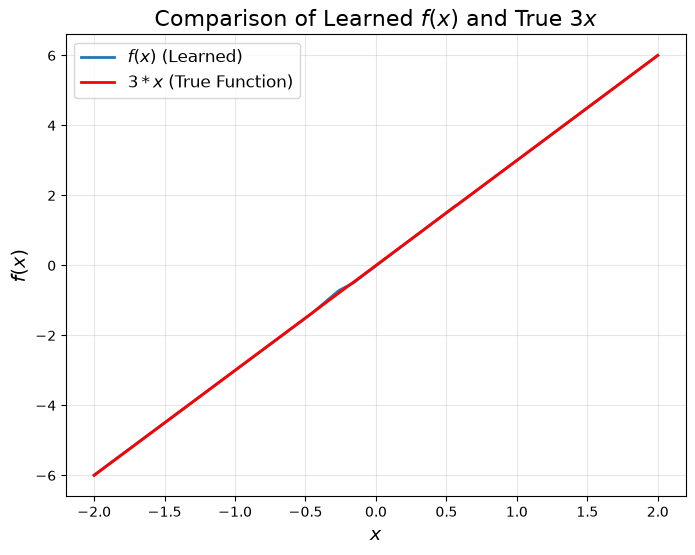

In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Fix random seeds for reproducibility (data generation and weight init)
np.random.seed(0)
torch.manual_seed(0)

# Generate random samples for x_i and y_i
x_samples = np.random.uniform(-2, 2, 1000).reshape(-1, 1)
y_samples = np.random.uniform(-2, 2, 1000).reshape(-1, 1)

# Compute x + y for functional equation training
xy_samples = x_samples + y_samples

# Convert samples to PyTorch tensors
x_samples_t = torch.tensor(x_samples, dtype=torch.float32)
y_samples_t = torch.tensor(y_samples, dtype=torch.float32)
xy_samples_t = torch.tensor(xy_samples, dtype=torch.float32)

# Build the neural network
class FunctionalNet(nn.Module):
    def __init__(self):
        super(FunctionalNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 10),  # First hidden layer with 10 neurons
            nn.ReLU(),
            # nn.Linear(10, 50),  # Second hidden layer
            # nn.ReLU(),
            nn.Linear(10, 1)  # Output layer
        )

    def forward(self, x):
        return self.net(x)

model = FunctionalNet()

# Define the custom loss function
def custom_loss(model, x_input, y_input, xy_input):
    # Functional equation loss: f(x+y) ≈ f(x)+f(y)
    f_x = model(x_input)  # f(x)
    f_y = model(y_input)  # f(y)
    f_xy = model(xy_input)  # f(x+y)

    functional_loss = torch.mean((f_xy - f_x - f_y) ** 2)

    # Boundary condition loss: f(1) ≈ 3
    f_1 = model(torch.tensor([[1.0]], dtype=torch.float32))  # f(1)
    boundary_loss = (f_1 - 3.0) ** 2

    # Total loss: L = L_fct + L_bd
    return functional_loss + boundary_loss.squeeze()

# Compile the model (optimizer setup)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
# NOTE: In the original Keras code, custom_loss ignores the batch Keras passes in
# and always recomputes on the FULL dataset (x_samples, y_samples, xy_samples).
# The batch_size=32 argument to model.fit only controls how many optimizer steps
# Keras performs per epoch: ceil(1000/32) = 32 steps/epoch, each one an update
# using the full-dataset loss. We replicate that here explicitly.
epochs = 30
batch_size = 32
steps_per_epoch = int(np.ceil(x_samples_t.shape[0] / batch_size))  # = 32

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        optimizer.zero_grad()
        loss = custom_loss(model, x_samples_t, y_samples_t, xy_samples_t)  # full dataset, like the original
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss/steps_per_epoch:.4f}")

# Predict and plot the function f(x)
x_plot = np.linspace(-2, 2, 1000).reshape(-1, 1)
x_plot_t = torch.tensor(x_plot, dtype=torch.float32)
with torch.no_grad():
    f_x_plot = model(x_plot_t).numpy()

# Compute the true function y = 3x for comparison
true_f_x = 3*x_plot

# Plot the learned function f(x) and the true function y = 3x
plt.figure(figsize=(8, 6))
plt.plot(x_plot, f_x_plot, label="$f(x)$ (Learned)", linewidth=2)
plt.plot(x_plot, true_f_x, label="$3*x$ (True Function)", linewidth=2, color='red')
plt.title("Comparison of Learned $f(x)$ and True $3x$", fontsize=16)
plt.xlabel("$x$", fontsize=14)
plt.ylabel("$f(x)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()